# 멀티레이블
정답(라벨)이 여러 개 존재한다  
맞는 것만 1로 리스트 형태로 만든다  

출력층에서 Sigmoid 활성화 함수를 통과하여 결과가 카테고리 개수만큼 나온다(0~1 확률)


ex)  
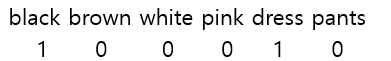


sigmoid , softmax 차이

- sigmoid  
멀티 레이블 분류에서 많이 씀. 각 클래스에 대한 독립적인(0~1 사이의) 확률값
- softmax  
단일 레이블 분류에서 많이 씀. 전체의 값을 더하면 1(여러 값 중 한 값만 뽑을 때. 가장 높은 확률의 것 뽑을 때)

### 이진 분류에서의 sigmoid

이진 분류는 두 클래스(예: 0과 1) 중 하나를 선택하는 문제  
**출력 노드가 한 개**  
Sigmoid 함수는 단일 로짓 값을 확률로 변환하며, 이 값은 클래스 1에 속할 확률을 의미  
클래스 0에 속할 확률 = (1 - 클래스 1에 속할 확률)  

(Softmax를 사용해서 출력층 2개로 이진 분류를 할 수는 있지만, Sigmoid가 더 간단하고 계산 효율적, 이진 분류에서는 두 클래스 확률의 합이 1임을 보장할 필요 없이, 하나의 확률 값만으로 충분히 문제를 해결할 수 있음)

Sigmoid 함수에서 출력층 노드가 2개 이상이라면 이는 멀티 레이블 분류 문제로 간주

In [ ]:
import torch
import torch.nn as nn

In [ ]:
sigmoid = nn.Sigmoid()

# 카테고리 0일 확률이 0.2689
result = torch.tensor([-1.,-2., 10., 1.])
sigmoid(result), sum(sigmoid(result))

(tensor([0.2689, 0.1192, 1.0000, 0.7311]), tensor(2.1192))

In [ ]:
softmax = nn.Softmax()

# 총 합이 1
result = torch.tensor([-1.,-2., 10., 1.])
softmax(result), sum(softmax(result))

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


(tensor([1.6699e-05, 6.1433e-06, 9.9985e-01, 1.2339e-04]), tensor(1.0000))

## 사용 데이터셋
fashion dataset

# fashion data csv 사용

In [6]:
import pandas as pd
from PIL import Image
import numpy as np

In [2]:
train_df = pd.read_csv('fashion_data/train.csv', index_col=0)
test_df = pd.read_csv('fashion_data/test.csv', index_col=0)

In [107]:
train_df.head()

,image,black,blue,brown,green,red,white,dress,shirt,pants,shorts,shoes
0,./clothes_dataset\blue_shorts\256d854b55ac32ea...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,./clothes_dataset\red_pants\584f778aece14f07c2...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,./clothes_dataset\green_pants\ec543ca241cefb2b...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,./clothes_dataset\brown_shorts\c8db9e0f7010592...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,./clothes_dataset\white_dress\551373c80717c5b0...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## 이미지 경로 슬라이싱

In [108]:
f"fashion_data/{train_df['image'][0][2:]}"

'fashion_data/clothes_dataset\\blue_shorts\\256d854b55ac32ea4d0d6398dffccc4d8909a388.jpg'

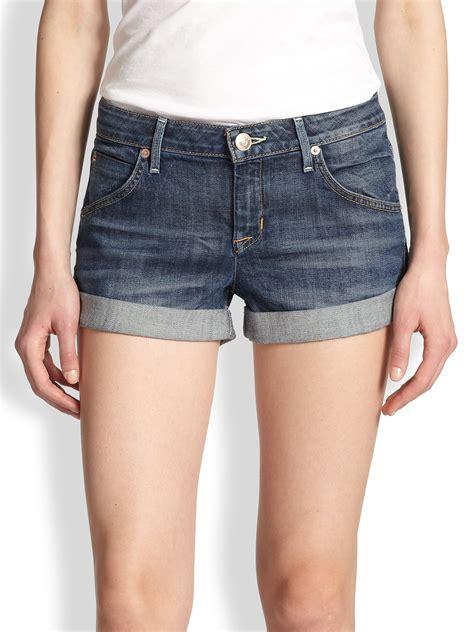

In [4]:
img = Image.open(f"fashion_data/{train_df['image'][0][2:]}")
img

In [7]:
np.array(img).shape

(632, 474, 3)

In [110]:
train_df['image'].head()

0    ./clothes_dataset\blue_shorts\256d854b55ac32ea...
1    ./clothes_dataset\red_pants\584f778aece14f07c2...
2    ./clothes_dataset\green_pants\ec543ca241cefb2b...
3    ./clothes_dataset\brown_shorts\c8db9e0f7010592...
4    ./clothes_dataset\white_dress\551373c80717c5b0...
Name: image, dtype: object

In [111]:
# label 리스트
train_df.iloc[:, 1:].shape

(5578, 11)

# 필요 라이브러리 임포트

In [103]:
import torch
import torch.nn as nn
from torch.optim import Adam # 최적화함수
from torch.utils.data import Dataset, DataLoader # 데이터셋 만들기
from torchvision import transforms, models # 전처리, pretrained 모델 가져오기
import numpy as np
import matplotlib.pyplot as plt
import tqdm

# csv로 되어 있는 데이터로 custom dataset 만들기

In [112]:
class Fashion(Dataset):
  def __init__(self, df, transform=None): # 이미지 경로와 정답이 있는 df, 전처리 transfrom 받기
    self.transform = transform
    self.data_list = df['image'].values
    self.label_list = df.iloc[:, 1:].values

  def __len__(self):
    return len(self.data_list)

  def __getitem__(self, idx):
    img_path = self.data_list[idx]
    img = Image.open(f'fashion_data/{img_path[2:]}')
    label = self.label_list[idx]

    if self.transform is not None:
      img = self.transform(img)

    return img, label

## 전처리

In [113]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 데이터셋 만들기

In [114]:
train_data = Fashion(train_df, transform=data_transform)
test_data = Fashion(test_df, transform=data_transform)

In [115]:
len(train_data)

5578

In [116]:
train_data.data_list

array(['./clothes_dataset\\blue_shorts\\256d854b55ac32ea4d0d6398dffccc4d8909a388.jpg',
       './clothes_dataset\\red_pants\\584f778aece14f07c2f386037c495cd7c2414c6d.jpg',
       './clothes_dataset\\green_pants\\ec543ca241cefb2b3a52fb6b0b27ed3164d22a47.jpg',
       ...,
       './clothes_dataset\\black_pants\\afa29481cd27a47574cbef22b2d981e812ce9af6.jpg',
       './clothes_dataset\\green_shoes\\aaeba68f98a07bf7638726013a978d9fd531e951.jpg',
       './clothes_dataset\\white_dress\\d58b9b44af5259330d36af0b2e2810ea956f237a.jpg'],
      shape=(5578,), dtype=object)

In [117]:
train_data.label_list

array([[0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5578, 11))

In [118]:
train_df.columns[1:]

Index(['black', 'blue', 'brown', 'green', 'red', 'white', 'dress', 'shirt',
       'pants', 'shorts', 'shoes'],
      dtype='object')

In [119]:
len(train_df.columns[1:])

11

In [245]:
category = train_df.columns[1:]
def imgshow(data, labels, transform=True):
  if transform:
    numpy_array = data.numpy()
    img = numpy_array.transpose((1, 2, 0))
  else:
    img = np.array(data)
  st = ''
  for i in range(11):
    if labels[i] == 1:
      st += category[i] + ' '
  plt.title(st)
  plt.axis('off')
  plt.imshow(img)

In [121]:
data, label = train_data[1]

In [122]:
data.shape

torch.Size([3, 224, 224])

In [123]:
label

array([0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.])

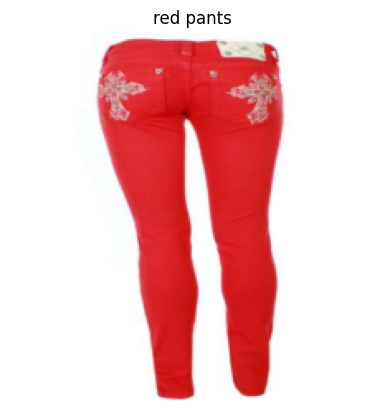

In [124]:
imgshow(data, label)

In [125]:
train_no_transform = Fashion(train_df)

In [126]:
d, l = train_no_transform[0]

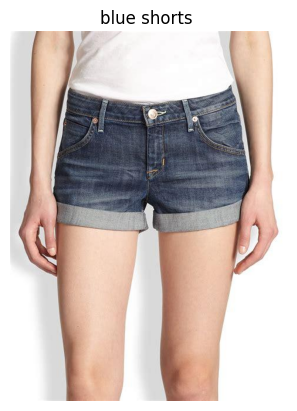

In [127]:
imgshow(d,l, transform=False)

## 데이터 로더 만들기

In [128]:
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(train_data, batch_size=16)

In [129]:
train_loader.batch_size

16

In [130]:
data, label = next(iter(train_loader))

In [131]:
data.shape

torch.Size([16, 3, 224, 224])

In [132]:
label.shape

torch.Size([16, 11])

In [135]:
label.size(0)

16

In [136]:
data[0].shape

torch.Size([3, 224, 224])

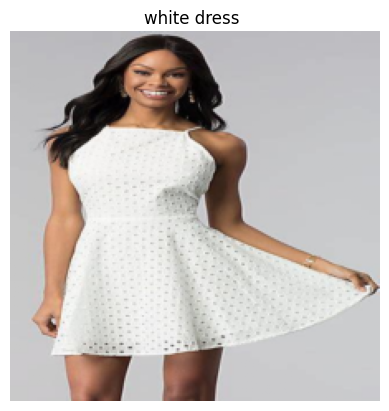

In [137]:
imgshow(data[0], label[0], True)

# 모델 정하기

## pretrained 모델 학습법

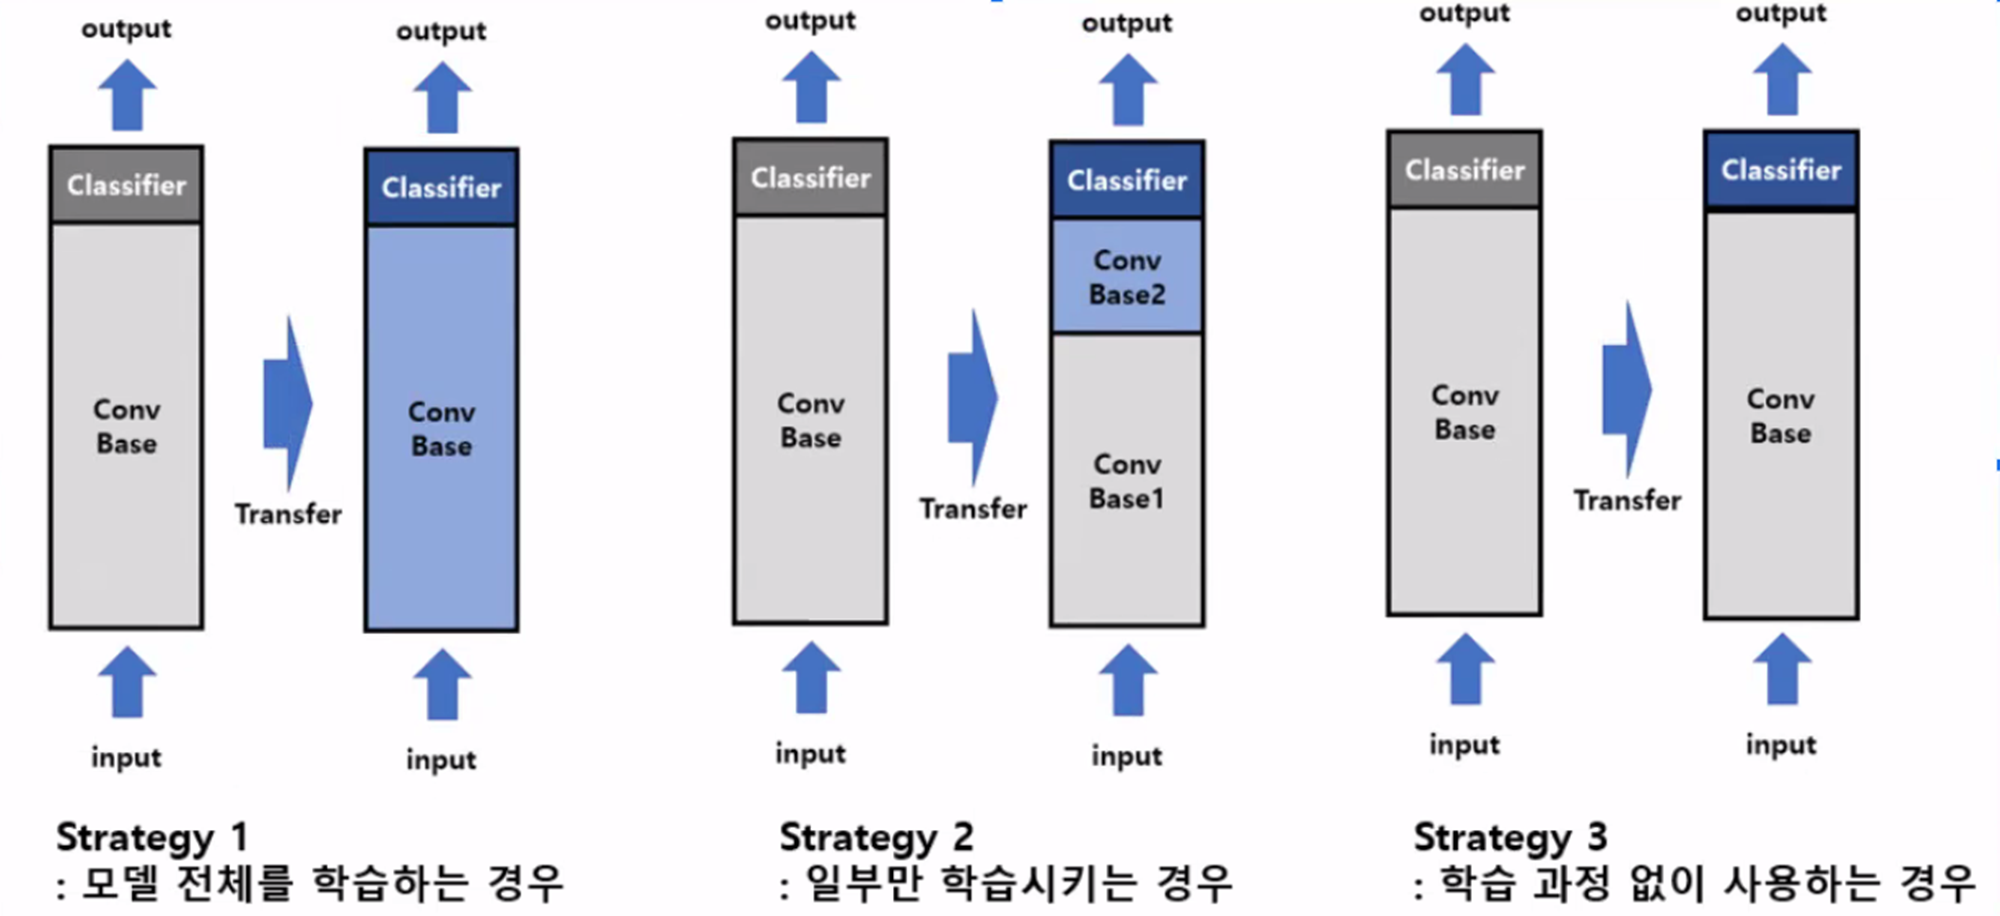

strategy 1
Full training   
모델 전체 학습  
데이터가 많은 경우 효율적

strategy 2  
Fine tuning  
상위는 학습시키지 않고 프리징  
내 클래스와 pretrained가 비슷할 때  

starategy 3  
Feature Extraction  
분류기(FC layer)만 재학습, 나머지는 프리징

프리징: 가중치 업데이트 안되게 grad=False로 한다


### 1. 전체 학습 (Full Training)
설명: 모델 전체를 학습시켜서 모든 가중치를 업데이트합니다.  
장점: 데이터가 많을 때 좋음(처음부터 끝까지 내 데이터에 맞는 최적의 모델을 만들 수 있음)  
단점: 많은 데이터와 시간, 계산 자원이 필요(이미 잘 학습된 가중치를 처음부터 다시 학습시키기 때문에, 비효율적일 수 있음)  
사용 경우: 내가 가진 데이터가 매우 많고, pretrained 모델과 전혀 다른 도메인일 때
### 2. Fine Tuning
설명: pretrained 모델의 일부 가중치는 고정(Freeze)하고, 나머지 일부만 업데이트  
보통 상위 레이어는 Freeze하고 하위 레이어(특화된 레이어)만 학습  
장점: pretrained 모델의 일반적인 특징을 유지하면서, 특정 데이터셋에 맞춰 세부 조정을 할 수 있음, 학습 속도가 빠르며, 상대적으로 적은 데이터로도 효과적  
단점: pretrained 모델이 사용하는 데이터와 내 데이터의 차이가 크면 성능이 저하될 수 있음  
사용 경우: pretrained 모델과 내 데이터가 유사한 도메인일 때  
예: 고양이와 개 사진 분류 → 강아지 품종 분류.
### 3. Feature Extraction
설명: pretrained 모델의 모든 레이어를 Freeze하고, 최상위 분류기(FC Layer)만 새로 학습  
기존 모델이 추출한 특징(feature)을 그대로 활용  
장점: 학습 속도가 매우 빠르고 작은 데이터셋으로도 학습이 가능  
단점: 내 데이터가 pretrained 모델의 도메인과 다르면 효과가 제한적  
사용 경우: 데이터셋이 매우 적거나, pretrained 모델과 내 데이터가 매우 유사할 때.
### 4. 프리징 (Freezing)
설명: 특정 레이어의 가중치가 업데이트되지 않도록 고정.
PyTorch 예시: param.requires_grad = False  
불필요한 계산 낭비를 줄이고, 모델의 기존 특징을 유지.  
Fine Tuning과 Feature Extraction에서 필수적으로 사용됨.  



딥러닝 학습 전략  
고려 포인트: 데이터셋 크기, pretrained 모델과의 도메인 유사성

데이터 많음 -> 전체 학습  
도메인 유사 -> Fine tuning  
데이터 적음 + 도메인 유사 -> Feature Extraction  

도메인 유사성이란  
pretrained 모델의 학습 데이터와 내 데이터셋의 내용, 스타일, 특징을 비교해 판단  

**도메인 유사성 판단 기준**  
**주요 비교 요소**
- 클래스: 모델이 학습한 클래스와 내 데이터의 클래스가 유사한지.
예: ImageNet은 일반 물체를 포함하므로, 강아지 품종 분류처럼 유사한 도메인에 적합.
- 스타일: 이미지의 전반적인 특징(색감, 구조 등).
예: ImageNet 모델은 사진 스타일에 최적화되어 있으나, 스케치나 의료 영상에는 맞지 않을 수 있음.
- 특징: 학습된 특징(엣지, 패턴 등)이 내 데이터셋에도 적용 가능한지.


데이터 확인은 공식 문서와 논문을 통해


## pretrained model 사용
resnet34

In [217]:
model = models.resnet34(pretrained=True)

In [218]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 프리징

- 모델이 가진 파라미터 뽑기 -> model.parameters()
- 모델 이름이랑 파라미터 뽑기 -> model.named_parameters()

In [219]:
for param in model.parameters():
  print(param.requires_grad)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [220]:
# 프리징
for parm in model.parameters():
  parm.requires_grad = False

In [221]:
for param in model.parameters():
  print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


## Feature extraction

In [222]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [223]:
# 내 데이터에 맞게
fc_layer = nn.Linear(512, 11)

In [224]:
model.fc = fc_layer

In [225]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [226]:
model.fc

Linear(in_features=512, out_features=11, bias=True)

In [227]:
# fc layer만 True(Feature extraction)
for name, param in model.named_parameters():
  print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer2.2.conv1.weight False
layer2.2.bn1.weight False
layer2.2.bn1

# 모델 학습

In [228]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [229]:
# gpu 쓴다면 model gpu로 옮기기
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [230]:
data = torch.rand((16, 3, 224, 224))
data.to(device)

model(data).shape

torch.Size([16, 11])

- torch.nn.BCELoss()  
sigmoid 적용이 안돼서 출력 값에 직접 torch.sigmoid()로 sigmoid 적용해야 함
- torch.nn.BCEWithLogitsLoss()  
내부적으로 sigmoid 연산 포함

In [170]:
y = torch.tensor([1., 2., -3])
target = torch.tensor([0.0, 1.0, 1.0])

bceloss = nn.BCELoss()
bcewithlogitloss = nn.BCEWithLogitsLoss()

print(bceloss(torch.sigmoid(y), target)) # sigmoid로 0~1 범위로 바꿔야 함
print(bcewithlogitloss(y, target))

tensor(1.4963)
tensor(1.4963)


### BCELoss로 했을 때

In [171]:
# 최적화함수, 손실함수, 에폭 정의
optimizer = Adam(model.parameters(), lr=0.0002)

criterion = nn.BCELoss() # 클래스 각각에 대한 확률값

epochs = 10

In [172]:
model.train()
loss_list = []
min_loss = int(1e9)

for epoch in range(epochs):
  epoch_loss = 0
  total_samples = 0

  for images, labels in tqdm.tqdm(train_loader):
    optimizer.zero_grad()

    y_pred = model(images.to(device))
    output = torch.sigmoid(y_pred).float()

    loss = criterion(output, labels.float().to(device))

    # 마지막 배치 사이즈가 다를 때
    epoch_loss += loss.item() * images.size(0) # 배치에 대한 평균 손실 * 배치 크기
    total_samples += images.size(0) # 배치 크기 누적

    loss.backward()
    optimizer.step()

  avg_loss = epoch_loss/total_samples # 한 에폭에 대한 평균 손실
  loss_list.append(avg_loss)
  print(f'epoch: {epoch}, loss: {avg_loss}')

  if avg_loss < min_loss:
    torch.save(model.state_dict(), f'multi_fashion_epoch_{epochs}.pth')
    min_loss = avg_loss

100%|█| 349/349 [09:58<00:00,  1.71


epoch: 0, loss: 0.36005510920348155


100%|█| 349/349 [08:41<00:00,  1.49


epoch: 1, loss: 0.2374017709106816


100%|████████████████████████████████████████████████████████████████████████████████████| 349/349 [07:55<00:00,  1.36s/it]


...

epoch: 7, loss: 0.12059120346874522


100%|████████████████████████████████████████████████████████████████████████████████████| 349/349 [08:43<00:00,  1.50s/it]


epoch: 8, loss: 0.1140573036610845


100%|████████████████████████████████████████████████████████████████████████████████████| 349/349 [08:43<00:00,  1.50s/it]

epoch: 9, loss: 0.1106758895458693


### BCEWithLogitsLoss로 했을 때

In [215]:
# 최적화함수, 손실함수, 에폭 정의
optimizer = Adam(model.parameters(), lr=1e-3)

criterion = nn.BCEWithLogitsLoss() # 클래스 각각에 대한 확률값

epochs = 10

In [233]:
model.train()
loss_list = []
min_loss = int(1e9)

for epoch in range(epochs):
  epoch_loss = 0
  total_samples = 0

  for images, labels in tqdm.tqdm(train_loader):
    optimizer.zero_grad()

    y_pred = model(images.to(device)).float()

    loss = criterion(y_pred, labels.float().to(device))

    # 마지막 배치 사이즈가 다를 때
    epoch_loss += loss.item() * images.size(0) # 배치에 대한 평균 손실 * 배치 크기
    total_samples += images.size(0) # 배치 크기 누적

    loss.backward()
    optimizer.step()

  avg_loss = epoch_loss/total_samples # 한 에폭에 대한 평균 손실
  loss_list.append(avg_loss)
  print(f'epoch: {epoch}, loss: {avg_loss}')

  if avg_loss < min_loss:
    torch.save(model.state_dict(), f'bce_multi_fashion_epoch_{epochs}.pth')
    min_loss = avg_loss

## 모델 시각화

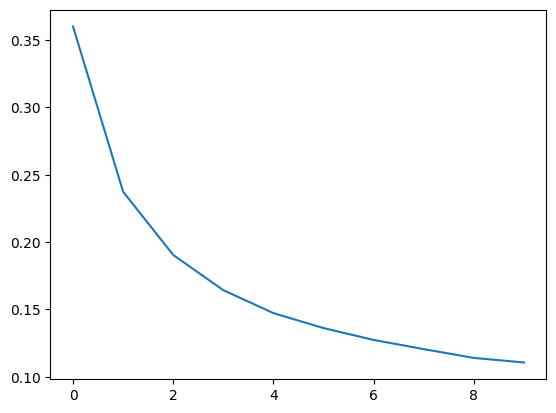

In [200]:
plt.plot(range(epochs),loss_list)
plt.show()

# 모델 검증

## 절차

In [184]:
datas, targets = next(iter(test_loader))

In [185]:
datas.shape

torch.Size([16, 3, 224, 224])

In [186]:
targets.shape

torch.Size([16, 11])

In [188]:
res = model(datas.to(device))
res.shape

torch.Size([16, 11])

In [190]:
res

tensor([[-1.1352e+00, -1.8957e-02, -3.7620e+00, -5.0122e+00, -4.8309e+00,
         -5.6811e-01, -4.2378e+00, -5.3698e+00, -3.4181e+00,  2.9335e+00,
         -2.9225e+00],
        [-3.4976e+00, -4.0688e+00, -6.4787e+00, -3.1344e+00,  2.8464e+00,
         -6.0320e+00, -6.2222e+00, -6.3817e+00,  3.7834e+00, -7.7343e+00,
         -4.1763e+00],
        [-1.6577e+00, -2.2920e+00, -5.1778e+00, -5.5130e-02, -3.5932e+00,
         -5.3934e+00, -4.7411e+00, -4.8914e+00,  9.9156e-01, -3.0625e+00,
         -5.6478e+00],
        [ 2.4221e+00, -3.0160e+00, -2.6529e+00, -5.7351e+00, -4.4612e+00,
         -3.4615e+00, -2.0782e+00, -4.0482e+00,  7.4421e-04, -1.1067e+00,
         -6.5432e+00],
        [-2.6707e+00, -2.1844e+00, -5.0038e+00, -4.7128e+00, -2.3530e+00,
          1.2442e+00,  4.1948e+00, -3.9607e+00, -4.6064e+00, -5.2693e+00,
         -4.7125e+00],
        [-1.4993e+00, -3.2945e-01, -8.1762e+00, -8.6628e+00, -1.5578e+00,
         -4.8572e+00,  7.2154e+00, -3.8737e+00, -5.1499e+00, -9.1983e+0

In [189]:
# sigmoid
torch.sigmoid(res) #  = nn.Sigmoid()(res)

tensor([[2.4321e-01, 4.9526e-01, 2.2709e-02, 6.6124e-03, 7.9165e-03, 3.6167e-01,
         1.4234e-02, 4.6335e-03, 3.1734e-02, 9.4948e-01, 5.1051e-02],
        [2.9381e-02, 1.6810e-02, 1.5334e-03, 4.1712e-02, 9.4513e-01, 2.3949e-03,
         1.9809e-03, 1.6893e-03, 9.7776e-01, 4.3738e-04, 1.5122e-02],
        [1.6007e-01, 9.1791e-02, 5.6088e-03, 4.8622e-01, 2.6773e-02, 4.5260e-03,
         8.6534e-03, 7.4551e-03, 7.2940e-01, 4.4680e-02, 3.5128e-03],
        [9.1849e-01, 4.6709e-02, 6.5809e-02, 3.2201e-03, 1.1417e-02, 3.0427e-02,
         1.1123e-01, 1.7154e-02, 5.0019e-01, 2.4849e-01, 1.4378e-03],
        [6.4722e-02, 1.0116e-01, 6.6677e-03, 8.8996e-03, 8.6828e-02, 7.7629e-01,
         9.8515e-01, 1.8694e-02, 9.8890e-03, 5.1208e-03, 8.9020e-03],
        [1.8254e-01, 4.1838e-01, 2.8118e-04, 1.7286e-04, 1.7396e-01, 7.7126e-03,
         9.9927e-01, 2.0358e-02, 5.7664e-03, 1.0120e-04, 2.6584e-04],
        [9.5547e-01, 4.7240e-02, 8.5028e-03, 1.9969e-03, 2.0744e-03, 3.8087e-03,
         1.04

In [194]:
# 각 값에 대한 확률값이 0.5 이상인 것만 True
nn.Sigmoid()(res) > 0.5

tensor([[False, False, False, False, False, False, False, False, False,  True,
         False],
        [False, False, False, False,  True, False, False, False,  True, False,
         False],
        [False, False, False, False, False, False, False, False,  True, False,
         False],
        [ True, False, False, False, False, False, False, False,  True, False,
         False],
        [False, False, False, False, False,  True,  True, False, False, False,
         False],
        [False, False, False, False, False, False,  True, False, False, False,
         False],
        [ True, False, False, False, False, False, False,  True, False, False,
         False],
        [ True, False, False, False, False, False, False,  True, False, False,
         False],
        [False, False, False, False, False, False, False, False, False, False,
          True],
        [False, False, False, False,  True, False, False, False,  True, False,
         False],
        [False, False, False, False, Fal

In [195]:
targets == 1

tensor([[False,  True, False, False, False, False, False, False, False,  True,
         False],
        [False, False, False, False,  True, False, False, False,  True, False,
         False],
        [False, False, False,  True, False, False, False, False,  True, False,
         False],
        [False, False,  True, False, False, False, False, False, False,  True,
         False],
        [False, False, False, False, False,  True,  True, False, False, False,
         False],
        [False,  True, False, False, False, False,  True, False, False, False,
         False],
        [ True, False, False, False, False, False, False,  True, False, False,
         False],
        [ True, False, False, False, False, False, False,  True, False, False,
         False],
        [False, False,  True, False, False, False, False, False, False, False,
          True],
        [False, False, False, False,  True, False, False, False,  True, False,
         False],
        [False,  True, False, False, Fal

In [197]:
correct = 0
for ouput, target in zip(nn.Sigmoid()(res) > 0.5, targets.to(device) == 1):
  # 다 같으면 True -> 정답
  if torch.equal(ouput, target):
    correct += 1

print(correct)

7


## 모델 평가

In [199]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for img,label in test_loader:
        pred = model(img.to(device))
        # 임계값(0.5) 이상인 것만
        result = nn.Sigmoid()(pred) > 0.5 # True, False 식으로

        targets = label.to(device) == 1 # True, False 식으로

        for output,target in zip(result,targets):
            if torch.equal(output,target): # 멀티 레이블이 다 일치하면 정답
                correct += 1

            total += 1 # 전체 개수

    print(f'acc {correct/total}')

acc 0.7794908569379706


## 시각화

In [236]:
mo = models.resnet34(pretrained=True)
for param in mo.parameters():
  param.requires_grad = False
mo.fc = nn.Linear(512, 11)
for name, param in mo.named_parameters():
  print(name, param.requires_grad)
# torch.load(mo.)

C:\Users\tjral\Desktop\교육\deep\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\tjral\Desktop\교육\deep\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer2.2.conv1.weight False
layer2.2.bn1.weight False
layer2.2.bn1

In [238]:
mo.load_state_dict(torch.load('multi_fashion_epoch_10.pth'))

C:\Users\tjral\AppData\Local\Temp\ipykernel_8612\3323112478.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mo.load_state_dict(torch.load('multi_fashion_epoch_10.pth'))


<All keys matched successfully>

In [241]:
data, label = next(iter(test_loader))
res = model(data)

In [242]:
res.shape

torch.Size([16, 11])

In [265]:
# 답
st = ''
l = label[4]
for i in range(11):
    if l[i] == 1:
      st += category[i] + ' '
print(st)

white dress 


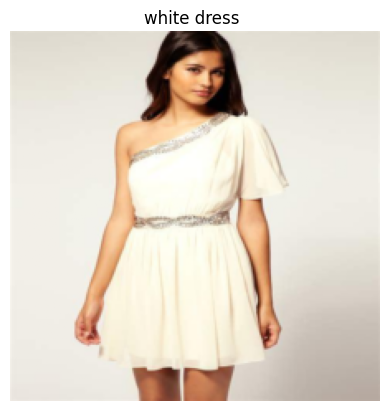

In [257]:
imgshow(data[4], nn.Sigmoid()(res[4])>0.5)

In [278]:
def check(data, res, target, num):
  data = data[num]
  numpy_array = data.numpy()
  img = numpy_array.transpose((1, 2, 0))
  real = ''
  predict = ''
  r = target[num]
  p = res[num]
  for i in range(11):
      if r[i] == 1:
        real += category[i] + ' '
      if nn.Sigmoid()(p[i]) > 0.5:
        predict += category[i] + ' '

  plt.title(f'real: {real}, predict: {predict}')
  plt.axis('off')
  plt.imshow(img)
  print(st)


white dress 


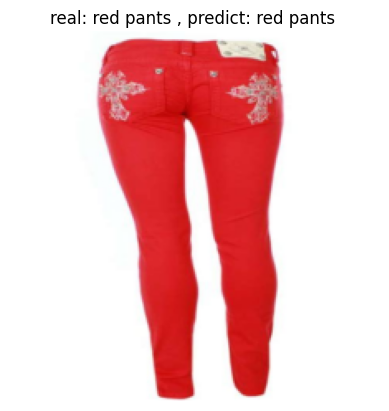

In [279]:
check(data, res, label, 1)

white dress 


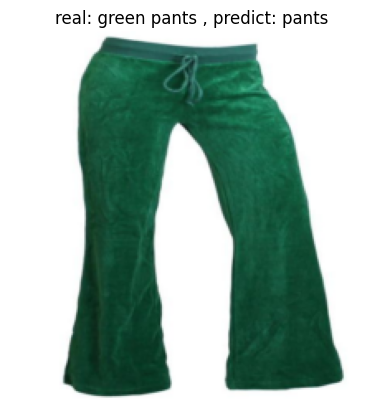

In [280]:
check(data, res, label, 2)

white dress 


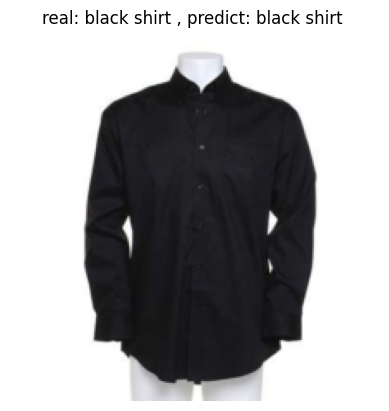

In [281]:
check(data, res, label, 6)

멀티 레이블 모델에 대한 성능이 잘 안나온다면  
멀티 모델을 만드는 게 더 나을 수도(색깔 모델, 옷 모델 합쳐서 쓰기)